# 4 동적 계획법 (Dynamic Programming)

## Figure 4.2

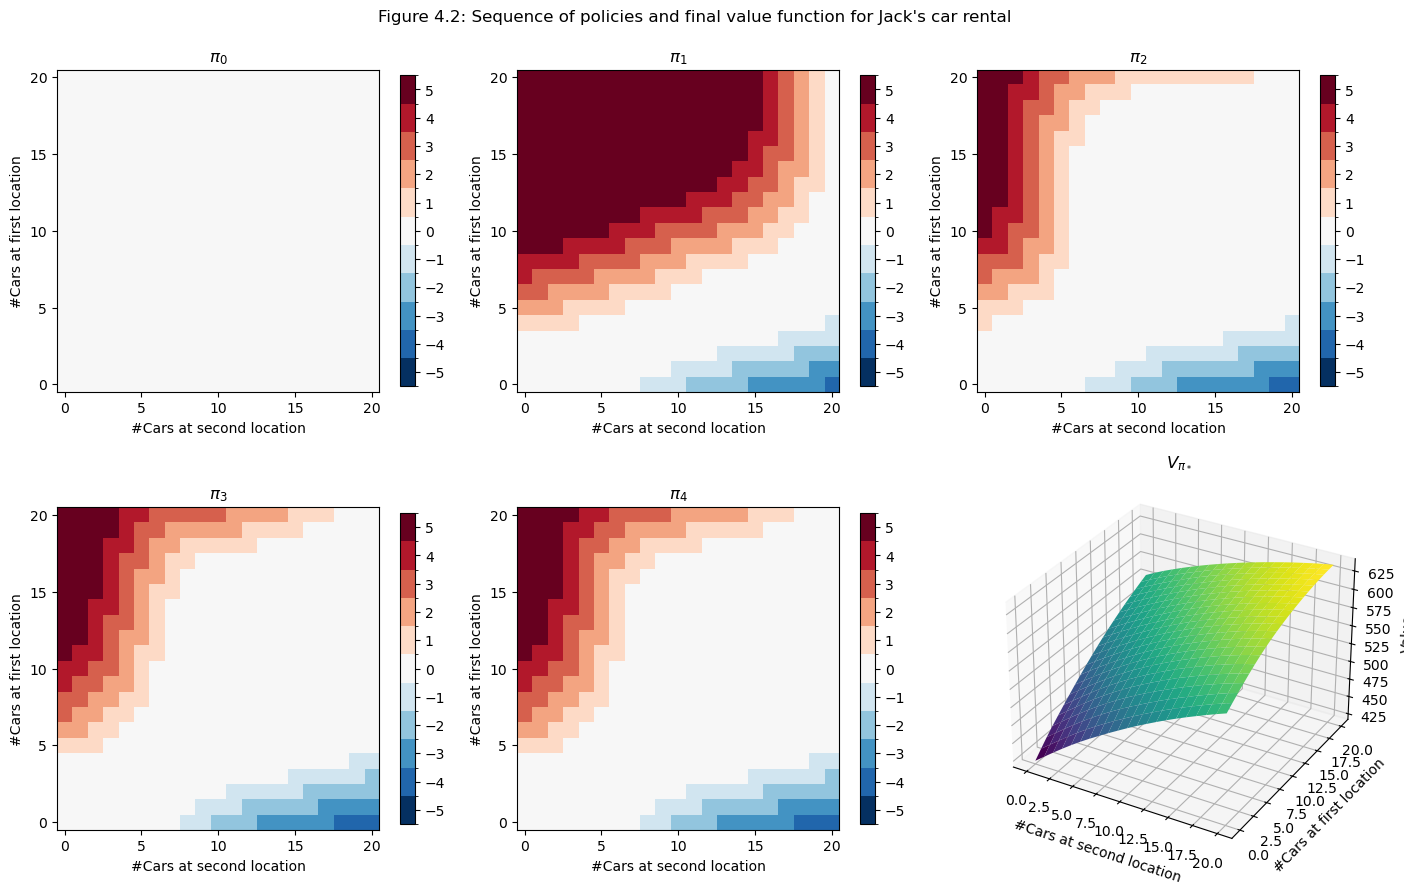

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import poisson

# 잭의 자동차 대여 문제 매개변수
MAX_CARS = 20            # 각 지점의 차량 보유 한도
MAX_MOVE = 5             # 하룻밤에 옮길 수 있는 차량의 최대 수
RENTAL_REWARD = 10       # 대여 한 건당 보상
MOVE_COST = 2            # 차량 한 대를 옮기는 데 드는 비용
GAMMA = 0.9              # 할인 인자

# 푸아송 매개변수: (지점 1 요청, 지점 2 요청, 지점 1 반환, 지점 2 반환)
LAMBDA_REQUEST = (3, 4)
LAMBDA_RETURN = (3, 2)

# 푸아송 분포의 꼬리를 자르기 위한 상한
POISSON_UPPER = 11


def poisson_pmf(lam: float, upper: int = POISSON_UPPER) -> np.ndarray:
    """0..upper 범위에서 잘라낸 푸아송 확률질량함수를 반환한다."""
    pmf = poisson.pmf(np.arange(upper + 1), lam)
    pmf[-1] += 1.0 - pmf.sum()  # 꼬리 확률을 마지막 값에 흡수
    return pmf


def location_dynamics(lam_request: float, lam_return: float) -> tuple[np.ndarray, np.ndarray]:
    """단일 지점에서 (시작 차량 수) -> (기대 보상, 종료 차량 수 분포)를 미리 계산한다.

    반환:
        expected_reward: shape (MAX_CARS + 1,)
        transition: shape (MAX_CARS + 1, MAX_CARS + 1) — transition[start, end]
    """
    request_pmf = poisson_pmf(lam_request)
    return_pmf = poisson_pmf(lam_return)

    expected_reward = np.zeros(MAX_CARS + 1)
    transition = np.zeros((MAX_CARS + 1, MAX_CARS + 1))

    for start in range(MAX_CARS + 1):
        for req, p_req in enumerate(request_pmf):
            rented = min(start, req)
            expected_reward[start] += p_req * rented * RENTAL_REWARD
            after_rent = start - rented
            for ret, p_ret in enumerate(return_pmf):
                end = min(after_rent + ret, MAX_CARS)
                transition[start, end] += p_req * p_ret
    return expected_reward, transition


# 두 지점의 동역학을 미리 계산해 둔다.
REWARD_1, TRANS_1 = location_dynamics(LAMBDA_REQUEST[0], LAMBDA_RETURN[0])
REWARD_2, TRANS_2 = location_dynamics(LAMBDA_REQUEST[1], LAMBDA_RETURN[1])


def expected_update(state: tuple[int, int], action: int, V: np.ndarray) -> float:
    """한 (state, action) 쌍에 대해 기대 갱신값을 계산한다.

    action > 0: 지점 1 -> 지점 2 로 |action| 대 이동
    action < 0: 지점 2 -> 지점 1 로 |action| 대 이동
    """
    cars1 = min(state[0] - action, MAX_CARS)
    cars2 = min(state[1] + action, MAX_CARS)
    if cars1 < 0 or cars2 < 0:
        return -np.inf  # 비현실적 행동은 차단

    move_cost = MOVE_COST * abs(action)
    immediate_reward = REWARD_1[cars1] + REWARD_2[cars2] - move_cost

    # 두 지점은 독립이므로 외적으로 결합
    next_value = TRANS_1[cars1] @ V[:, :] @ TRANS_2[cars2]
    return immediate_reward + GAMMA * next_value


def policy_evaluation(policy: np.ndarray, V: np.ndarray, theta: float = 1e-3) -> np.ndarray:
    """제자리 반복 정책 평가."""
    while True:
        delta = 0.0
        for i in range(MAX_CARS + 1):
            for j in range(MAX_CARS + 1):
                old = V[i, j]
                V[i, j] = expected_update((i, j), int(policy[i, j]), V)
                delta = max(delta, abs(old - V[i, j]))
        if delta < theta:
            break
    return V


def policy_improvement(policy: np.ndarray, V: np.ndarray) -> tuple[np.ndarray, bool]:
    """각 상태에서 q-값이 최대가 되는 행동을 골라 정책을 갱신한다."""
    stable = True
    for i in range(MAX_CARS + 1):
        for j in range(MAX_CARS + 1):
            old_action = policy[i, j]
            actions = range(-min(MAX_MOVE, j), min(MAX_MOVE, i) + 1)
            q_values = [expected_update((i, j), a, V) for a in actions]
            policy[i, j] = list(actions)[int(np.argmax(q_values))]
            if old_action != policy[i, j]:
                stable = False
    return policy, stable


# 정책 반복 실행
V = np.zeros((MAX_CARS + 1, MAX_CARS + 1))
policy = np.zeros_like(V, dtype=int)
policies = [policy.copy()]

while True:
    V = policy_evaluation(policy, V)
    policy, stable = policy_improvement(policy, V)
    policies.append(policy.copy())
    if stable:
        break

# 시각화: 정책 변화와 최종 가치 함수
fig = plt.figure(figsize=(14, 9))
fig.suptitle("Figure 4.2: Sequence of policies and final value function for Jack's car rental")

policy_levels = np.arange(-MAX_MOVE - 0.5, MAX_MOVE + 1.5)
policy_cmap = plt.get_cmap("RdBu_r", len(policy_levels) - 1)
policy_norm = BoundaryNorm(policy_levels, policy_cmap.N)

for idx, pi in enumerate(policies[:5]):
    ax = fig.add_subplot(2, 3, idx + 1)
    im = ax.imshow(pi, origin="lower", cmap=policy_cmap, norm=policy_norm)
    ax.set_title(rf"$\pi_{idx}$")
    ax.set_xlabel("#Cars at second location")
    ax.set_ylabel("#Cars at first location")
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_yticks([0, 5, 10, 15, 20])
    fig.colorbar(im, ax=ax, ticks=range(-MAX_MOVE, MAX_MOVE + 1), shrink=0.8)

ax = fig.add_subplot(2, 3, 6, projection="3d")
X, Y = np.meshgrid(np.arange(MAX_CARS + 1), np.arange(MAX_CARS + 1))
ax.plot_surface(X, Y, V, cmap="viridis", edgecolor="none")
ax.set_title(r"$V_{\pi_*}$")
ax.set_xlabel("#Cars at second location")
ax.set_ylabel("#Cars at first location")
ax.set_zlabel("Value")

plt.tight_layout()
plt.show()

## Figure 4.3

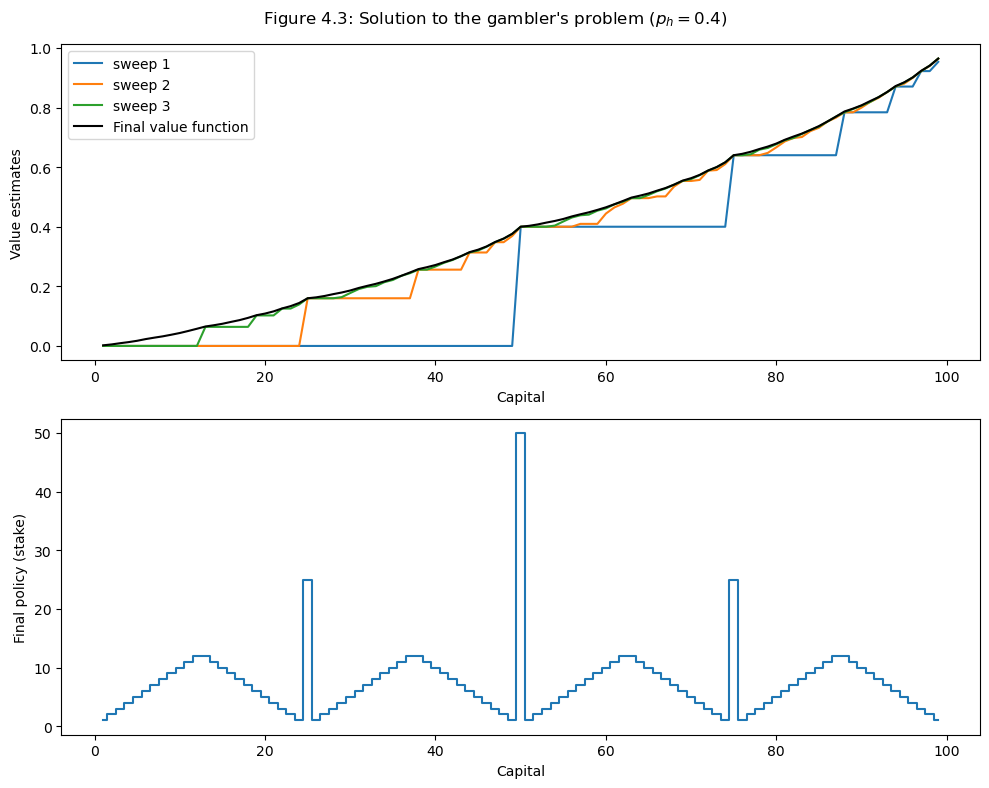

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 도박사 문제 매개변수
GOAL = 100        # 도달해야 할 목표 자본
PH = 0.4          # 동전이 앞면일 확률
THETA = 1e-9      # 가치 반복 종료 임계값


def value_iteration(p_h: float, goal: int = GOAL, theta: float = THETA) -> tuple[np.ndarray, np.ndarray, list[np.ndarray]]:
    """도박사 문제에 대한 가치 반복.

    반환:
        V: 최종 가치 함수, shape (goal + 1,)
        policy: 각 자본에서의 최적 베팅, shape (goal + 1,)
        snapshots: 1, 2, 3, 32번째 스윕 직후의 가치 함수 스냅샷
    """
    V = np.zeros(goal + 1)
    V[goal] = 1.0  # 목표 도달은 +1 보상
    snapshots: dict[int, np.ndarray] = {}
    sweep = 0

    while True:
        sweep += 1
        delta = 0.0
        for s in range(1, goal):
            actions = np.arange(1, min(s, goal - s) + 1)
            returns = p_h * V[s + actions] + (1 - p_h) * V[s - actions]
            best = returns.max()
            delta = max(delta, abs(V[s] - best))
            V[s] = best
        if sweep in (1, 2, 3, 32):
            snapshots[sweep] = V.copy()
        if delta < theta:
            break

    # 최적 정책: 각 상태에서 기대값을 최대로 하는 베팅
    policy = np.zeros(goal + 1, dtype=int)
    for s in range(1, goal):
        actions = np.arange(1, min(s, goal - s) + 1)
        returns = p_h * V[s + actions] + (1 - p_h) * V[s - actions]
        # 부동소수점 동률을 어느 정도 흡수해 가장 작은 합법 베팅을 고른다.
        policy[s] = actions[np.argmax(np.round(returns, 5))]

    ordered = [snapshots[k] for k in sorted(snapshots)]
    return V, policy, ordered


V_final, policy, snapshots = value_iteration(PH)

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle(rf"Figure 4.3: Solution to the gambler's problem ($p_h = {PH}$)")

labels = ["sweep 1", "sweep 2", "sweep 3", "sweep 32"]
for snap, label in zip(snapshots, labels):
    axes[0].plot(np.arange(1, GOAL), snap[1:GOAL], label=label)
axes[0].plot(np.arange(1, GOAL), V_final[1:GOAL], label="Final value function", color="black")
axes[0].set_xlabel("Capital")
axes[0].set_ylabel("Value estimates")
axes[0].legend()

axes[1].step(np.arange(1, GOAL), policy[1:GOAL], where="mid")
axes[1].set_xlabel("Capital")
axes[1].set_ylabel("Final policy (stake)")

plt.tight_layout()
plt.show()